# AUTO ARIMA

## IMPORTS

In [2]:
# Dataset import
from ucimlrepo import fetch_ucirepo

# General imports
import numpy as np
import pandas as pd 

# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns

#Model import
from pmdarima import auto_arima

#Validation import
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox

#Results import
from tqdm.notebook import tqdm
from sklearn.metrics import mean_absolute_error

## DATASET LOADING

In [4]:
# fetch dataset 
bike_sharing = fetch_ucirepo(id=275) 
  
# original df 
df = bike_sharing.data.original

# variable information 
print(bike_sharing.variables)

print(df.head())

          name     role         type demographic  \
0      instant       ID      Integer        None   
1       dteday  Feature         Date        None   
2       season  Feature  Categorical        None   
3           yr  Feature  Categorical        None   
4         mnth  Feature  Categorical        None   
5           hr  Feature  Categorical        None   
6      holiday  Feature       Binary        None   
7      weekday  Feature  Categorical        None   
8   workingday  Feature       Binary        None   
9   weathersit  Feature  Categorical        None   
10        temp  Feature   Continuous        None   
11       atemp  Feature   Continuous        None   
12         hum  Feature   Continuous        None   
13   windspeed  Feature   Continuous        None   
14      casual    Other      Integer        None   
15  registered    Other      Integer        None   
16         cnt   Target      Integer        None   

                                          description units mis

## AUTO ARIMA MODELING

### Data preparation

In [5]:
df['dteday'] = pd.to_datetime(df['dteday'])

train_size = int(len(df) * 0.80)
train, test = df.iloc[:train_size], df.iloc[train_size:]

train_registered_log = np.log1p(train["registered"])
train_casual_log = np.log1p(train["casual"])

y_test_registered_log = np.log1p(test["registered"])
y_test_casual_log = np.log1p(test["casual"])

exog_cols = ['temp', 'hum', 'windspeed', 'workingday', 'holiday']
X_train = train[exog_cols]
X_test = test[exog_cols]

### Model training

#### Without seasonality (ARIMA)

In [5]:
# Model adjustment non-seasonal
#Registered model
model_reg_no_seas = auto_arima(train_registered_log, 
                               seasonal=False, 
                               stepwise=True,
                               suppress_warnings=True,
                               trace=True)

#Casual model
model_cas_no_seas = auto_arima(train_casual_log, 
                               seasonal=False, 
                               stepwise=True, 
                               suppress_warnings=True, 
                               trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=15.26 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=28230.286, Time=0.97 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=24805.275, Time=0.69 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=25336.876, Time=3.58 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=28228.287, Time=0.33 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=24718.130, Time=1.63 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=24107.520, Time=2.88 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=23850.834, Time=4.30 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : AIC=23835.646, Time=4.52 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=22040.144, Time=23.85 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=17.17 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=36.48 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=36.57 sec
 ARIMA(5,1,1)(0,0,0)[0]             : AIC=inf, Time=12.25 sec

Best model:  ARIMA(5,1,1)(0,0,0)[0] interc

#### With seasonality (SARIMA)

In [6]:
# Model adjustment seasonal
#Registered model
model_reg_seas = auto_arima(train_registered_log, 
                               seasonal=True,
                               m = 24,
                               max_p=2, max_q=2,
                               max_P=1, max_Q=1,
                               stepwise=True,
                               suppress_warnings=True,
                               trace=True)

#Casual model
model_cas_seas = auto_arima(train_casual_log, 
                               seasonal=True,
                               m = 24,
                               max_p=2, max_q=2,
                               max_P=1, max_Q=1,
                               stepwise=True, 
                               suppress_warnings=True,
                               trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=16032.864, Time=143.88 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=28230.286, Time=2.59 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=20332.531, Time=28.38 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=22137.811, Time=33.81 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=28228.287, Time=1.97 sec
 ARIMA(2,1,2)(0,0,1)[24] intercept   : AIC=inf, Time=484.42 sec
 ARIMA(2,1,2)(1,0,0)[24] intercept   : AIC=17639.304, Time=490.27 sec
 ARIMA(2,1,2)(0,0,0)[24] intercept   : AIC=inf, Time=103.27 sec
 ARIMA(1,1,2)(1,0,1)[24] intercept   : AIC=19315.357, Time=364.84 sec
 ARIMA(2,1,1)(1,0,1)[24] intercept   : AIC=19430.213, Time=358.20 sec
 ARIMA(1,1,1)(1,0,1)[24] intercept   : AIC=19471.400, Time=109.88 sec
 ARIMA(2,1,2)(1,0,1)[24]             : AIC=inf, Time=119.93 sec

Best model:  ARIMA(2,1,2)(1,0,1)[24] intercept
Total fit time: 2241.775 seconds
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0

#### With seasonality and exogenous variables (SARIMAX)

In [ ]:
#Registered model
model_reg_seas_exog = auto_arima(train_registered_log, 
                               seasonal=True,
                               X = X_train,
                               max_p=2, max_q=2,
                               max_P=1, max_Q=1,
                               m = 24,
                               stepwise=True,
                               suppress_warnings=True,
                               trace=True)

#Casual model
model_cas_seas_exog = auto_arima(train_casual_log, 
                               seasonal=True,
                               X = X_train,
                               max_p=2, max_q=2,
                               max_P=1, max_Q=1,
                               m = 24,
                               stepwise=True, 
                               suppress_warnings=True,
                               trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=16557.259, Time=192.49 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=27991.307, Time=2.09 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=20270.178, Time=87.79 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=22061.091, Time=111.47 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=27989.307, Time=7.16 sec
 ARIMA(2,1,2)(0,0,1)[24] intercept   : AIC=18988.832, Time=197.09 sec
 ARIMA(2,1,2)(1,0,0)[24] intercept   : AIC=17743.200, Time=208.21 sec
 ARIMA(2,1,2)(0,0,0)[24] intercept   : AIC=21752.375, Time=44.46 sec
 ARIMA(1,1,2)(1,0,1)[24] intercept   : AIC=17718.015, Time=197.95 sec
 ARIMA(2,1,1)(1,0,1)[24] intercept   : AIC=19410.671, Time=135.77 sec
 ARIMA(1,1,1)(1,0,1)[24] intercept   : AIC=19448.230, Time=154.84 sec
 ARIMA(2,1,2)(1,0,1)[24]             : AIC=15784.478, Time=142.53 sec
 ARIMA(2,1,2)(0,0,1)[24]             : AIC=inf, Time=146.17 sec
 ARIMA(2,1,2)(1,0,0)[24]             : AIC=inf, Time=145.50

### Save Models

In [17]:
sm_res_reg_no_seas = model_reg_no_seas.arima_res_
sm_res_reg_no_seas.save("model_reg_no_seas.pkl")
sm_res_cas_no_seas = model_cas_no_seas.arima_res_
sm_res_cas_no_seas.save("model_cas_no_seas.pkl")
sm_res_reg_seas = model_reg_seas.arima_res_
sm_res_reg_seas.save("model_reg_seas.pkl")
sm_res_cas_seas = model_cas_seas.arima_res_
sm_res_cas_seas.save("model_cas_seas.pkl")
sm_res_reg_seas_exog = model_reg_seas_exog.arima_res_
sm_res_reg_seas_exog.save("model_reg_seas_exog.pkl")
sm_res_cas_seas_exog = model_cas_seas_exog.arima_res_
sm_res_cas_seas_exog.save("model_cas_seas_exog.pkl")

### Validation phase

#### No Seasonality Validation

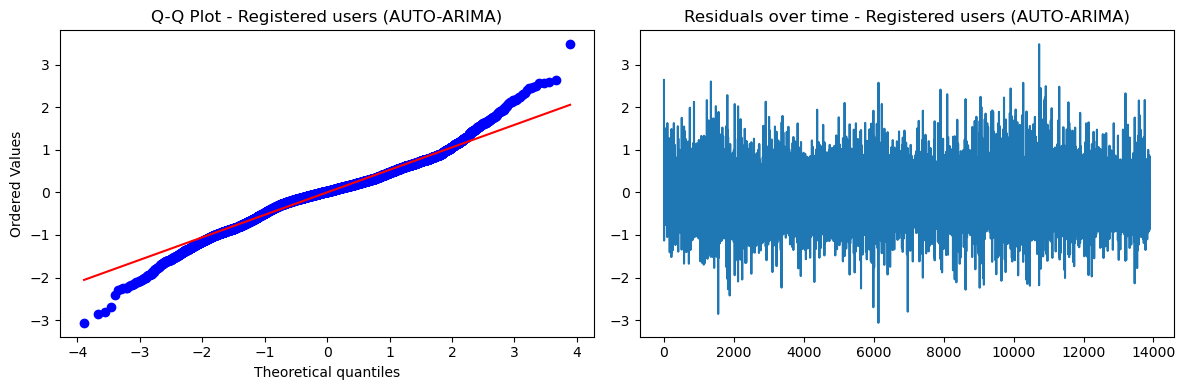

        lb_stat      lb_pvalue
10   556.010117  4.636687e-113
20  1218.512829  8.188258e-246


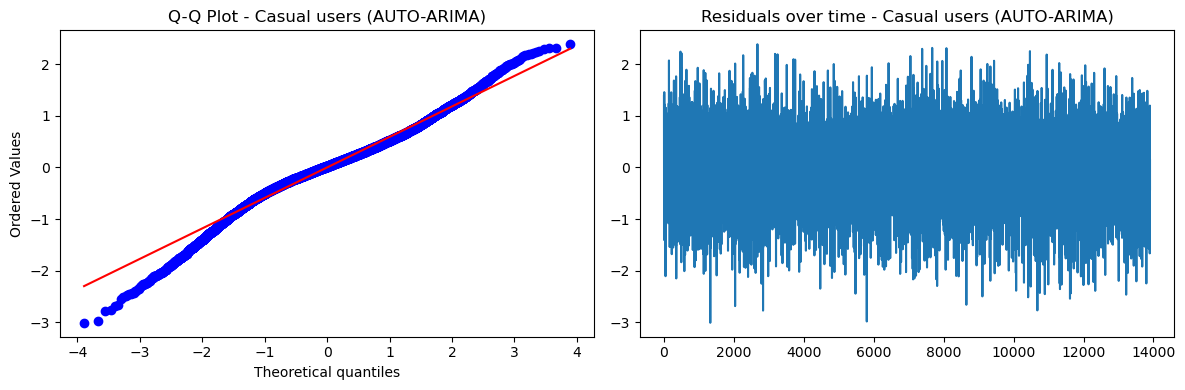

        lb_stat      lb_pvalue
10   360.679064   2.154641e-71
20  1203.481341  1.345247e-242


In [8]:
#Registered odel validation
residuals_registered = model_reg_no_seas.resid()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(residuals_registered, dist="norm", plot=axes[0])
axes[0].set_title(f"Q-Q Plot - Registered users (AUTO-ARIMA)")
axes[1].plot(residuals_registered)
axes[1].set_title(f"Residuals over time - Registered users (AUTO-ARIMA)")
plt.tight_layout()
plt.show()

lb_result = acorr_ljungbox(residuals_registered, lags=[10, 20], return_df=True)
print(lb_result)

#Casual model validation
residuals_casual = model_cas_no_seas.resid()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(residuals_casual, dist="norm", plot=axes[0])
axes[0].set_title(f"Q-Q Plot - Casual users (AUTO-ARIMA)")
axes[1].plot(residuals_casual)
axes[1].set_title(f"Residuals over time - Casual users (AUTO-ARIMA)")
plt.tight_layout()
plt.show()

lb_result = acorr_ljungbox(residuals_casual, lags=[10, 20], return_df=True)
print(lb_result)

#### Seasonality Validation

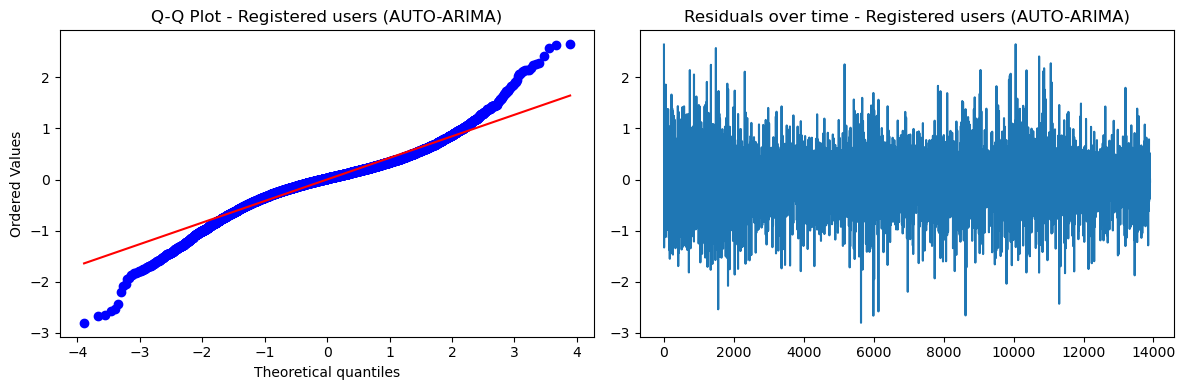

       lb_stat     lb_pvalue
10  139.805424  4.619616e-25
20  232.720164  3.408477e-38


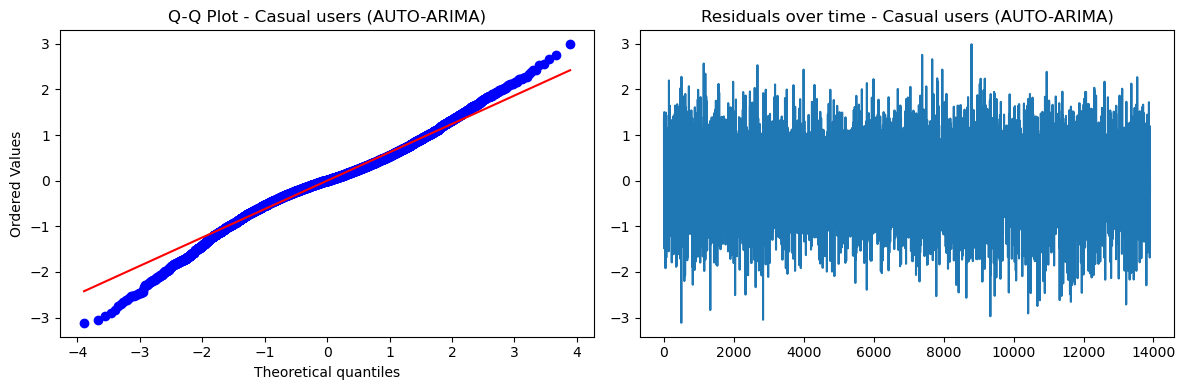

       lb_stat      lb_pvalue
10  327.824297   2.007956e-64
20  737.059687  3.152980e-143


In [ ]:
#Registered odel validation
residuals_registered = model_reg_seas.resid()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(residuals_registered, dist="norm", plot=axes[0])
axes[0].set_title(f"Q-Q Plot - Registered users (AUTO-SARIMA)")
axes[1].plot(residuals_registered)
axes[1].set_title(f"Residuals over time - Registered users (AUTO-SARIMA)")
plt.tight_layout()
plt.show()

lb_result = acorr_ljungbox(residuals_registered, lags=[10, 20], return_df=True)
print(lb_result)

#Casual model validation
residuals_casual = model_cas_seas.resid()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(residuals_casual, dist="norm", plot=axes[0])
axes[0].set_title(f"Q-Q Plot - Casual users (AUTO-SARIMA)")
axes[1].plot(residuals_casual)
axes[1].set_title(f"Residuals over time - Casual users (AUTO-ARIMA)")
plt.tight_layout()
plt.show()

lb_result = acorr_ljungbox(residuals_casual, lags=[10, 20], return_df=True)
print(lb_result)

#### Seasonality and exogenus Validation

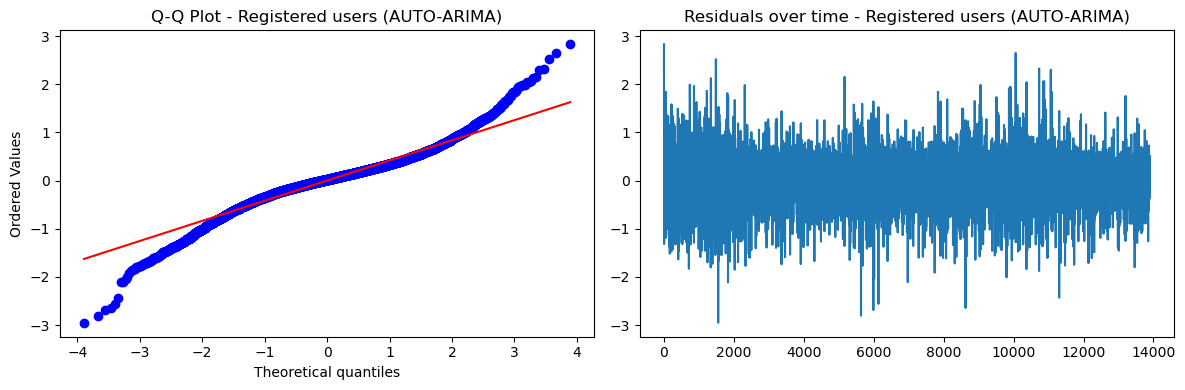

       lb_stat     lb_pvalue
10  141.571457  2.007266e-25
20  240.276266  1.036440e-39


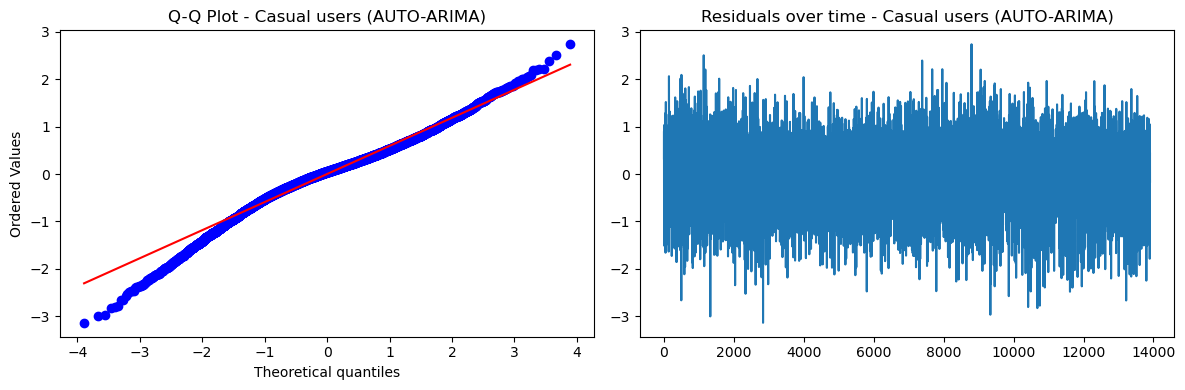

       lb_stat     lb_pvalue
10  221.015894  6.549866e-42
20  469.558901  6.755502e-87


In [ ]:
#Registered odel validation
residuals_registered = model_reg_seas_exog.resid()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(residuals_registered, dist="norm", plot=axes[0])
axes[0].set_title(f"Q-Q Plot - Registered users (AUTO-SARIMAX)")
axes[1].plot(residuals_registered)
axes[1].set_title(f"Residuals over time - Registered users (AUTO-SARIMAX)")
plt.tight_layout()
plt.show()

lb_result = acorr_ljungbox(residuals_registered, lags=[10, 20], return_df=True)
print(lb_result)

#Casual model validation
residuals_casual = model_cas_seas_exog.resid()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(residuals_casual, dist="norm", plot=axes[0])
axes[0].set_title(f"Q-Q Plot - Casual users (AUTO-SARIMAX)")
axes[1].plot(residuals_casual)
axes[1].set_title(f"Residuals over time - Casual users (AUTO-SARIMAX)")
plt.tight_layout()
plt.show()

lb_result = acorr_ljungbox(residuals_casual, lags=[10, 20], return_df=True)
print(lb_result)

### Results

#### No Seasonality

Starting Walk-Forward for 144 days...


Simulating days:   0%|          | 0/145 [00:00<?, ?it/s]


--- FINAL RESULT WALK-FORWARD (140 days) ---
MAE CNT(AUTO-SARIMA): 146.57
MAE REGISTERED(AUTO-SARIMA): 138.55
MAE CASUAL(AUTO-SARIMA): 21.87
-------------------------------
WMAPE CNT(AUTO-SARIMA): 58.92%
WMAPE REGISTERED(AUTO-SARIMA): 67.09%
WMAPE CASUAL(AUTO-SARIMA): 51.79%
-------------------------------
ACCURACY CNT(AUTO-SARIMA): 41.08%
ACCURACY REGISTERED(AUTO-SARIMA): 32.91%
ACCURACY CASUAL(AUTO-SARIMA): 48.21%


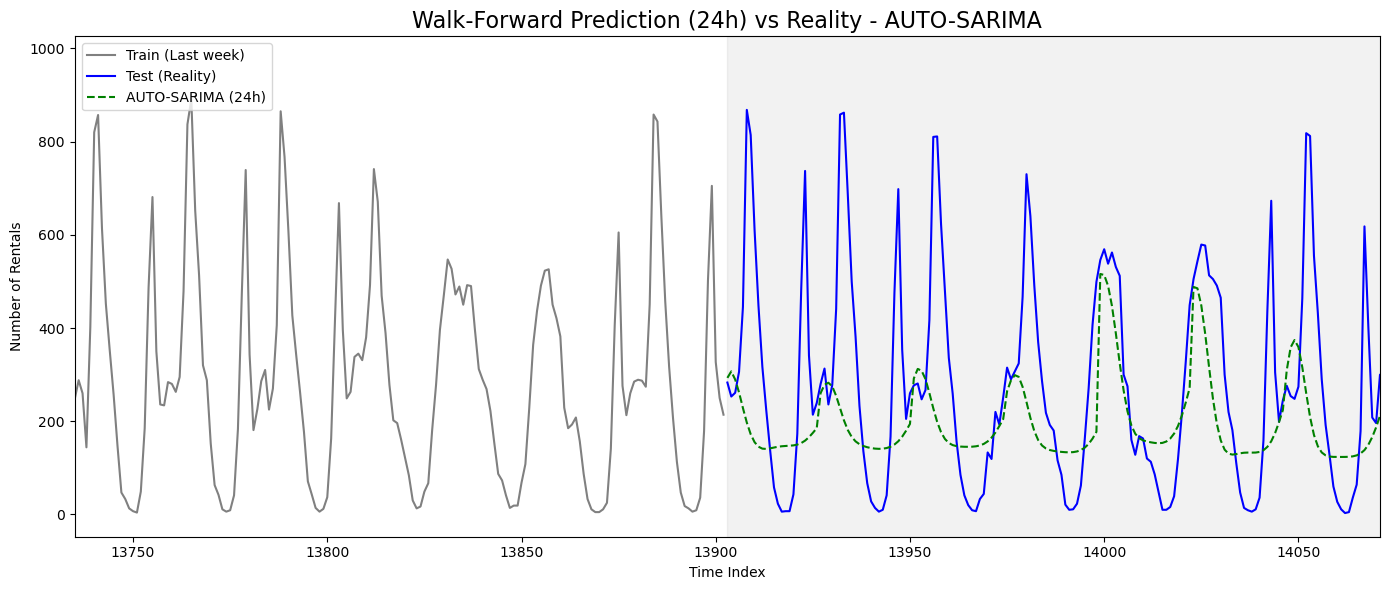

In [ ]:
test_length = len(y_test_registered_log) 
step_size = 24

sm_res_reg_no_seas = model_reg_no_seas.arima_res_
sm_res_cas_no_seas = model_cas_no_seas.arima_res_

final_preds_reg = []
final_preds_cas = []
all_final_preds = []

print(f"Starting Walk-Forward for {test_length // 24} days...")

# =====================================================================
# WALK-FORWARD LOOP
# =====================================================================
for i in tqdm(range(0, test_length, step_size), desc="Simulating days"):
    
    # Predict the next 24 hours (or remaining hours if less than 24) in log scale
    current_step = min(step_size, test_length - i)
    
    pred_reg_log = sm_res_reg_no_seas.forecast(steps=current_step)
    pred_cas_log = sm_res_cas_no_seas.forecast(steps=current_step)
    
    # invert the log transformation to get predictions in original scale
    pred_reg = np.expm1(pred_reg_log)
    pred_cas = np.expm1(pred_cas_log)
    
    # Sum all predictions to get total count
    final_preds_reg.extend(pred_reg)
    final_preds_cas.extend(pred_cas)
    all_final_preds.extend(pred_reg + pred_cas)
    
    # Obtain the actual data for the next 24 hours (in log scale) to update the models
    actual_reg_log = y_test_registered_log.iloc[i : i + current_step]
    actual_cas_log = y_test_casual_log.iloc[i : i + current_step]
    
    # Update the models with the actual data (in log scale) without refitting
    sm_res_reg_no_seas = sm_res_reg_no_seas.append(actual_reg_log, refit=False)
    sm_res_cas_no_seas = sm_res_cas_no_seas.append(actual_cas_log, refit=False)

# =====================================================================
# FINAL EVALUATION
# =====================================================================
final_pred_series = pd.Series(all_final_preds, index=test[:len(all_final_preds)].index)

final_pred_reg = pd.Series(final_preds_reg, index=test[:len(final_preds_reg)].index)

final_pred_cas = pd.Series(final_preds_cas, index=test[:len(final_preds_cas)].index)

actual_reg = test['registered'].iloc[:len(all_final_preds)]
actual_cas = test['casual'].iloc[:len(all_final_preds)]
actual_cnt = test['cnt'].iloc[:len(all_final_preds)]

print(f"\n--- FINAL RESULT WALK-FORWARD (140 days) ---")
mae_cnt = mean_absolute_error(actual_cnt, final_pred_series)
mae_reg = mean_absolute_error(actual_reg, final_pred_reg)
mae_cas = mean_absolute_error(actual_cas, final_pred_cas)

wmape_cnt = np.sum(np.abs(actual_cnt - final_pred_series)) / np.sum(actual_cnt)
wmape_reg = np.sum(np.abs(actual_reg - final_pred_reg)) / np.sum(actual_reg)
wmape_cas = np.sum(np.abs(actual_cas - final_pred_cas)) / np.sum(actual_cas)

accuracy_cnt = 1 - wmape_cnt
accuracy_reg = 1 - wmape_reg
accuracy_cas = 1 - wmape_cas

label = "AUTO-ARIMA"
print(f"MAE CNT({label}): {mae_cnt:.2f}")
print(f"MAE REGISTERED({label}): {mae_reg:.2f}")
print(f"MAE CASUAL({label}): {mae_cas:.2f}")
print("-------------------------------")
print(f"WMAPE CNT({label}): {wmape_cnt * 100:.2f}%")
print(f"WMAPE REGISTERED({label}): {wmape_reg * 100:.2f}%")
print(f"WMAPE CASUAL({label}): {wmape_cas * 100:.2f}%")
print("-------------------------------")
print(f"ACCURACY CNT({label}): {accuracy_cnt * 100:.2f}%")
print(f"ACCURACY REGISTERED({label}): {accuracy_reg * 100:.2f}%")
print(f"ACCURACY CASUAL({label}): {accuracy_cas * 100:.2f}%")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train["cnt"].index[-168:], train["cnt"].iloc[-168:], label='Train (Last week)', color='gray')
ax.plot(actual_cnt.index, actual_cnt, label='Test (Reality)', color='blue')
ax.plot(actual_cnt.index, final_pred_series, label=f'{label} (24h)', color='green', linestyle='--')
ax.axvspan(actual_cnt.index[0], actual_cnt.index[-1], color='#808080', alpha=0.1)
ax.set_title(f'Walk-Forward Prediction (24h) vs Reality - {label}', fontsize=16)
ax.set_xlabel('Time Index')
ax.set_ylabel('Number of Rentals')
ax.legend(loc='upper left')
ax.set_xlim(train.index[-168], actual_cnt.index[min(168, len(actual_cnt)-1)])
plt.tight_layout()
plt.show()

#### Seasonality

Starting Walk-Forward for 144 days...


Simulando días:   0%|          | 0/145 [00:00<?, ?it/s]


--- FINAL RESULT WALK-FORWARD (140 days) ---
MAE CNT(AUTO-SARIMA): 96.93
MAE REGISTERED(AUTO-SARIMA): 82.55
MAE CASUAL(AUTO-SARIMA): 27.08
-------------------------------
WMAPE CNT(AUTO-SARIMA): 38.97%
WMAPE REGISTERED(AUTO-SARIMA): 39.97%
WMAPE CASUAL(AUTO-SARIMA): 64.13%
-------------------------------
ACCURACY CNT(AUTO-SARIMA): 61.03%
ACCURACY REGISTERED(AUTO-SARIMA): 60.03%
ACCURACY CASUAL(AUTO-SARIMA): 35.87%


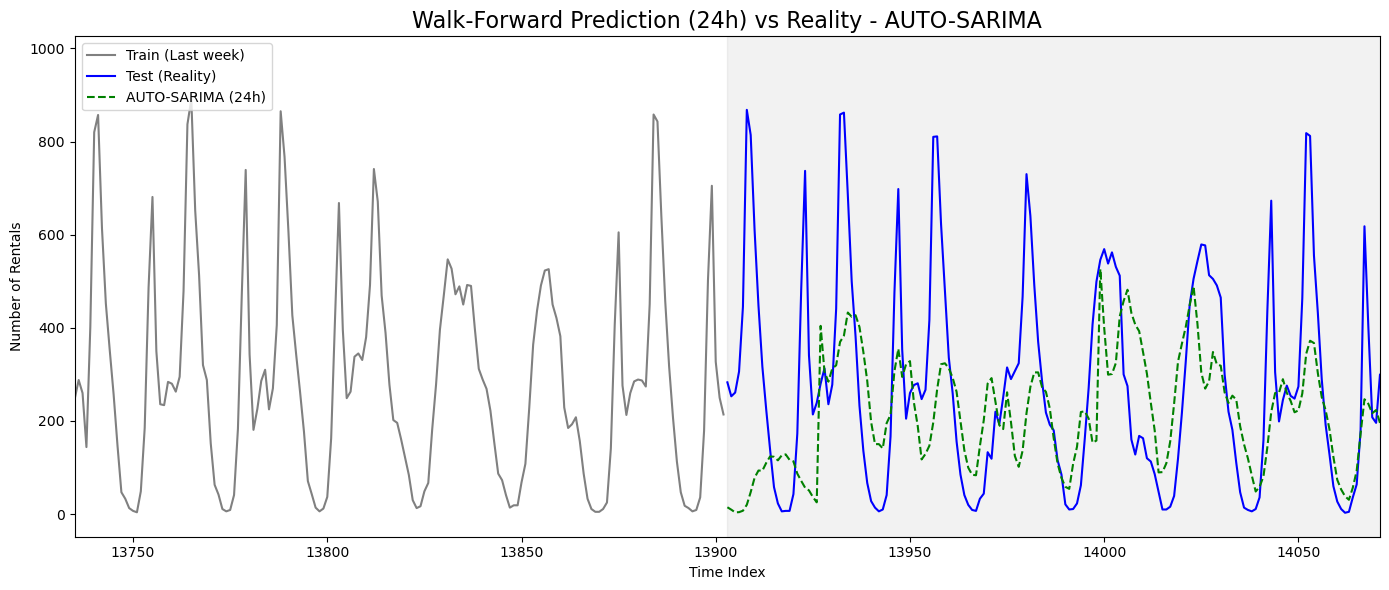

In [ ]:
test_length = len(y_test_registered_log) 
step_size = 24

sm_res_reg_seas = model_reg_seas.arima_res_
sm_res_cas_seas = model_cas_seas.arima_res_

final_preds_reg = []
final_preds_cas = []
all_final_preds = []

print(f"Starting Walk-Forward for {test_length // 24} days...")

# =====================================================================
# WALK-FORWARD LOOP
# =====================================================================
for i in tqdm(range(0, test_length, step_size), desc="Simulando días"):
    
    # predict the next 24 hours (or remaining hours if less than 24) in log scale
    current_step = min(step_size, test_length - i)
    
    pred_reg_log = sm_res_reg_seas.forecast(steps=current_step)
    pred_cas_log = sm_res_cas_seas.forecast(steps=current_step)
        
    # Invert the log transformation to get predictions in original scale
    pred_reg = np.expm1(pred_reg_log)
    pred_cas = np.expm1(pred_cas_log)
    
    # Sum all predictions to get total count
    final_preds_reg.extend(pred_reg)
    final_preds_cas.extend(pred_cas)
    all_final_preds.extend(pred_reg + pred_cas)
    
    # Obtain the actual data for the next 24 hours (in log scale) to update the models
    # Extract the actual data that has just "passed"
    actual_reg_log = y_test_registered_log.iloc[i : i + current_step]
    actual_cas_log = y_test_casual_log.iloc[i : i + current_step]
    
    sm_res_reg_seas = sm_res_reg_seas.append(actual_reg_log, refit=False)
    sm_res_cas_seas = sm_res_cas_seas.append(actual_cas_log, refit=False)

# =====================================================================
# FINAL EVALUATION
# =====================================================================
final_pred_series = pd.Series(all_final_preds, index=test[:len(all_final_preds)].index)

final_pred_reg = pd.Series(final_preds_reg, index=test[:len(final_preds_reg)].index)

final_pred_cas = pd.Series(final_preds_cas, index=test[:len(final_preds_cas)].index)

actual_reg = test['registered'].iloc[:len(all_final_preds)]
actual_cas = test['casual'].iloc[:len(all_final_preds)]
actual_cnt = test['cnt'].iloc[:len(all_final_preds)]

print(f"\n--- FINAL RESULT WALK-FORWARD (140 days) ---")
mae_cnt = mean_absolute_error(actual_cnt, final_pred_series)
mae_reg = mean_absolute_error(actual_reg, final_pred_reg)
mae_cas = mean_absolute_error(actual_cas, final_pred_cas)

wmape_cnt = np.sum(np.abs(actual_cnt - final_pred_series)) / np.sum(actual_cnt)
wmape_reg = np.sum(np.abs(actual_reg - final_pred_reg)) / np.sum(actual_reg)
wmape_cas = np.sum(np.abs(actual_cas - final_pred_cas)) / np.sum(actual_cas)

accuracy_cnt = 1 - wmape_cnt
accuracy_reg = 1 - wmape_reg
accuracy_cas = 1 - wmape_cas

label = "AUTO-SARIMA"
print(f"MAE CNT({label}): {mae_cnt:.2f}")
print(f"MAE REGISTERED({label}): {mae_reg:.2f}")
print(f"MAE CASUAL({label}): {mae_cas:.2f}")
print("-------------------------------")
print(f"WMAPE CNT({label}): {wmape_cnt * 100:.2f}%")
print(f"WMAPE REGISTERED({label}): {wmape_reg * 100:.2f}%")
print(f"WMAPE CASUAL({label}): {wmape_cas * 100:.2f}%")
print("-------------------------------")
print(f"ACCURACY CNT({label}): {accuracy_cnt * 100:.2f}%")
print(f"ACCURACY REGISTERED({label}): {accuracy_reg * 100:.2f}%")
print(f"ACCURACY CASUAL({label}): {accuracy_cas * 100:.2f}%")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train["cnt"].index[-168:], train["cnt"].iloc[-168:], label='Train (Last week)', color='gray')
ax.plot(actual_cnt.index, actual_cnt, label='Test (Reality)', color='blue')
ax.plot(actual_cnt.index, final_pred_series, label=f'{label} (24h)', color='green', linestyle='--')
ax.axvspan(actual_cnt.index[0], actual_cnt.index[-1], color='#808080', alpha=0.1)
ax.set_title(f'Walk-Forward Prediction (24h) vs Reality - {label}', fontsize=16)
ax.set_xlabel('Time Index')
ax.set_ylabel('Number of Rentals')
ax.legend(loc='upper left')
ax.set_xlim(train.index[-168], actual_cnt.index[min(168, len(actual_cnt)-1)])
plt.tight_layout()
plt.show()

#### Seasonality and exogenus variables

Starting Walk-Forward for 144 days...


Simulating days:   0%|          | 0/145 [00:00<?, ?it/s]


--- FINAL RESULT WALK-FORWARD (140 days) ---
MAE CNT(AUTO-SARIMAX): 84.82
MAE REGISTERED(AUTO-SARIMAX): 71.91
MAE CASUAL(AUTO-SARIMAX): 20.54
-------------------------------
WMAPE CNT(AUTO-SARIMAX): 34.10%
WMAPE REGISTERED(AUTO-SARIMAX): 34.82%
WMAPE CASUAL(AUTO-SARIMAX): 48.65%
-------------------------------
ACCURACY CNT(AUTO-SARIMAX): 65.90%
ACCURACY REGISTERED(AUTO-SARIMAX): 65.18%
ACCURACY CASUAL(AUTO-SARIMAX): 51.35%


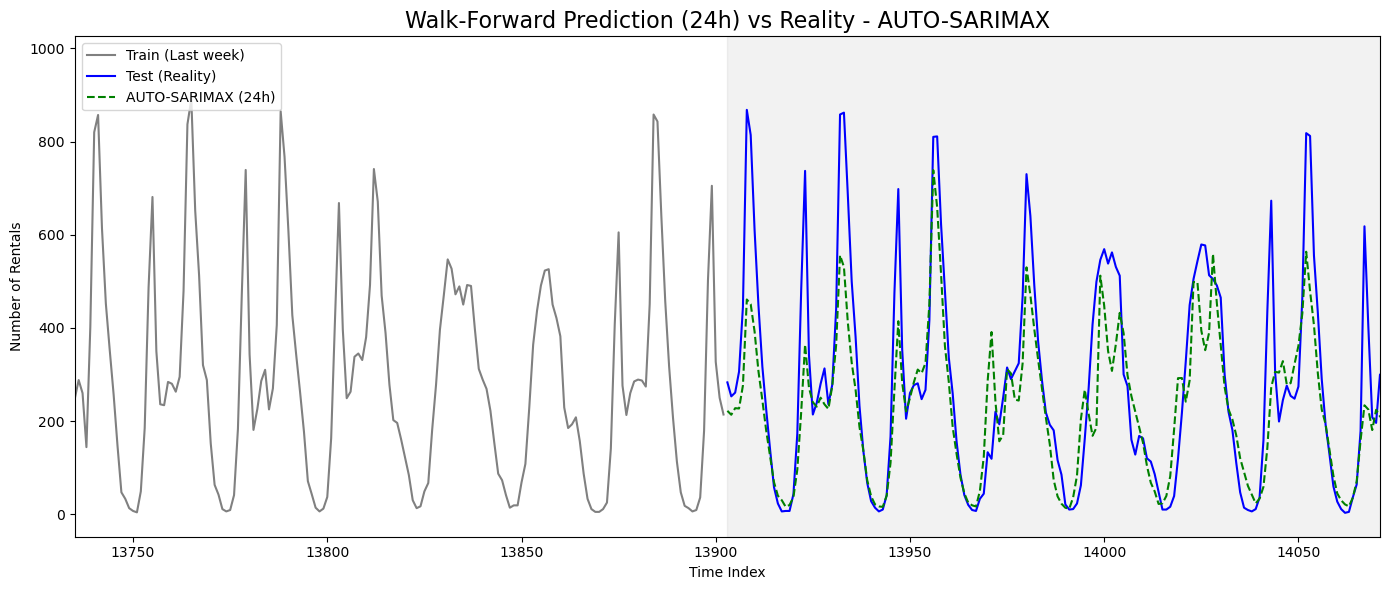

In [27]:
test_length = len(y_test_registered_log) 
step_size = 24

sm_res_reg_seas_exog = model_reg_seas_exog.arima_res_
sm_res_cas_seas_exog = model_cas_seas_exog.arima_res_

final_preds_reg = []
final_preds_cas = []
all_final_preds = []

print(f"Starting Walk-Forward for {test_length // 24} days...")

# =====================================================================
# 2. BUCLE WALK-FORWARD
# =====================================================================
for i in tqdm(range(0, test_length, step_size), desc="Simulating days"):
    
    current_step = min(step_size, test_length - i)
    exog_chunk = X_test.iloc[i : i + current_step]
    
    # --- CAMBIO 1: USAR FORECAST (NO PREDICT) Y EL OBJETO SM_RES ---
    pred_reg_log = sm_res_reg_seas_exog.forecast(steps=current_step, exog=exog_chunk)
    pred_cas_log = sm_res_cas_seas_exog.forecast(steps=current_step, exog=exog_chunk)
    
    # B. Invertir la transformación logarítmica (Pasar a nº de bicis)
    pred_reg = np.expm1(pred_reg_log)
    pred_cas = np.expm1(pred_cas_log)
    
    # C. Sumar ambas predicciones y guardarlas
    final_preds_reg.extend(pred_reg)
    final_preds_cas.extend(pred_cas)
    all_final_preds.extend(pred_reg + pred_cas)
    
    # D. ACTUALIZAR con la realidad
    actual_reg_log = y_test_registered_log.iloc[i : i + current_step]
    actual_cas_log = y_test_casual_log.iloc[i : i + current_step]
    
    # --- CAMBIO 2: USAR .values PARA EVITAR EL VALUEERROR DE PANDAS ---
    sm_res_reg_seas_exog = sm_res_reg_seas_exog.append(actual_reg_log.values, refit=False, exog=exog_chunk.values)
    sm_res_cas_seas_exog = sm_res_cas_seas_exog.append(actual_cas_log.values, refit=False, exog=exog_chunk.values)

# =====================================================================
# 3. EVALUACIÓN FINAL
# =====================================================================
# Convertimos a serie para comparar con el 'cnt' real de test
final_pred_series = pd.Series(all_final_preds, index=test[:len(all_final_preds)].index)

final_pred_reg = pd.Series(final_preds_reg, index=test[:len(final_preds_reg)].index)

final_pred_cas = pd.Series(final_preds_cas, index=test[:len(final_preds_cas)].index)

actual_reg = test['registered'].iloc[:len(all_final_preds)]
actual_cas = test['casual'].iloc[:len(all_final_preds)]
actual_cnt = test['cnt'].iloc[:len(all_final_preds)]

print(f"\n--- FINAL RESULT WALK-FORWARD (140 days) ---")
mae_cnt = mean_absolute_error(actual_cnt, final_pred_series)
mae_reg = mean_absolute_error(actual_reg, final_pred_reg)
mae_cas = mean_absolute_error(actual_cas, final_pred_cas)

wmape_cnt = np.sum(np.abs(actual_cnt - final_pred_series)) / np.sum(actual_cnt)
wmape_reg = np.sum(np.abs(actual_reg - final_pred_reg)) / np.sum(actual_reg)
wmape_cas = np.sum(np.abs(actual_cas - final_pred_cas)) / np.sum(actual_cas)

accuracy_cnt = 1 - wmape_cnt
accuracy_reg = 1 - wmape_reg
accuracy_cas = 1 - wmape_cas

label = "AUTO-SARIMAX"
print(f"MAE CNT({label}): {mae_cnt:.2f}")
print(f"MAE REGISTERED({label}): {mae_reg:.2f}")
print(f"MAE CASUAL({label}): {mae_cas:.2f}")
print("-------------------------------")
print(f"WMAPE CNT({label}): {wmape_cnt * 100:.2f}%")
print(f"WMAPE REGISTERED({label}): {wmape_reg * 100:.2f}%")
print(f"WMAPE CASUAL({label}): {wmape_cas * 100:.2f}%")
print("-------------------------------")
print(f"ACCURACY CNT({label}): {accuracy_cnt * 100:.2f}%")
print(f"ACCURACY REGISTERED({label}): {accuracy_reg * 100:.2f}%")
print(f"ACCURACY CASUAL({label}): {accuracy_cas * 100:.2f}%")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train["cnt"].index[-168:], train["cnt"].iloc[-168:], label='Train (Last week)', color='gray')
ax.plot(actual_cnt.index, actual_cnt, label='Test (Reality)', color='blue')
ax.plot(actual_cnt.index, final_pred_series, label=f'{label} (24h)', color='green', linestyle='--')
ax.axvspan(actual_cnt.index[0], actual_cnt.index[-1], color='#808080', alpha=0.1)
ax.set_title(f'Walk-Forward Prediction (24h) vs Reality - {label}', fontsize=16)
ax.set_xlabel('Time Index')
ax.set_ylabel('Number of Rentals')
ax.legend(loc='upper left')
ax.set_xlim(train.index[-168], actual_cnt.index[min(168, len(actual_cnt)-1)])
plt.tight_layout()
plt.show()